# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a naive bayes classifier model will be used in order to classify the different regions in the world that will show up in the data set, World Happiness Report in 2024 (Link: https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated/data). The columns used will be log GDP for each country and the Ladder Score of 0-10 representing the happiness or specifically the satisfaction with one's life in each country. The model will use the aforementioned feature sets to predict the region at country is in and then do the same prediction based on the Log GDP and Life Expectancy.

## Questions:
Through the selected columns of the data set, questions that may be answered through the model's predictions are:
##### How Much Impact Could The Log GDP Of Each Country Have On The Predicted Positions Of Their Respective World Regions According To Their Ladder Score?
##### Would There Be Regions With Similar Log GDPs But Different Ladder Scores?
##### How Much Impact Could The Log GDP Of Each Country Have On The Predicted Positions Of Their Respective World Regions According To Their Life Expectancy?
##### How Well Can The Model Predict A The Region Of A Country Based On The Above Feature Sets?

## Setting Up Data
In the cell below, the necessary imports are made and the data from the columns are read and placed into a 2d array to act as coordinates for plotting the data.

In [68]:
#Importing Dependencies
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.patches as ptch 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import seaborn as sns

df = pd.read_csv('World-happiness-report-2024.csv').dropna() #Dropping columns with missing data and reading the dataset 

logGDP = df['Log GDP per capita'].values  #Using .values as reading with pandas turns the data into a different format (pandas series) 
happiness = df['Ladder score'].values
regional_indicator = df['Regional indicator'].values

plt.style.use('seaborn-v0_8-whitegrid')
coordinates = np.column_stack((logGDP, happiness)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Score

Here, the colours for each region in the data set are assigned as a dictionary and then each region is assigned an integer value through the label encoder for the model to read. The regions are placed in a list after being read from the label encoder as it keeps all the labels through the .classes method.The output of this cell are all the regions involved.

In [69]:
region_colours = { #Assigning colours to each region
    "Western Europe":"Blue",
    "Middle East and North Africa":"Orange",
    "North America and ANZ":"Red",
    "Latin America and Caribbean":"Yellow",
    "Central and Eastern Europe":"Brown",
    "Southeast Asia":"Green",
    "East Asia":"Magenta",
    "Commonwealth of Independent States":"Cyan",
    "Sub-Saharan Africa":"Pink",
    "South Asia":"Grey"
}

le = LabelEncoder()
numerical_regions = le.fit_transform(df['Regional indicator'])  #Converting categorical data (regions) to numerical format (Regions are listed alphabetically and then indexed)

regions = list(le.classes_) #.classes holds the label for each category 

In the cell below, further sets up is made as the regions are read from the list and the associated colours are assigned an index. The colours assigned are then given to each numbered index that will be used by the model. The add_legend method uses patches to assign colours to labels to make the graph easier to read after scattering them.

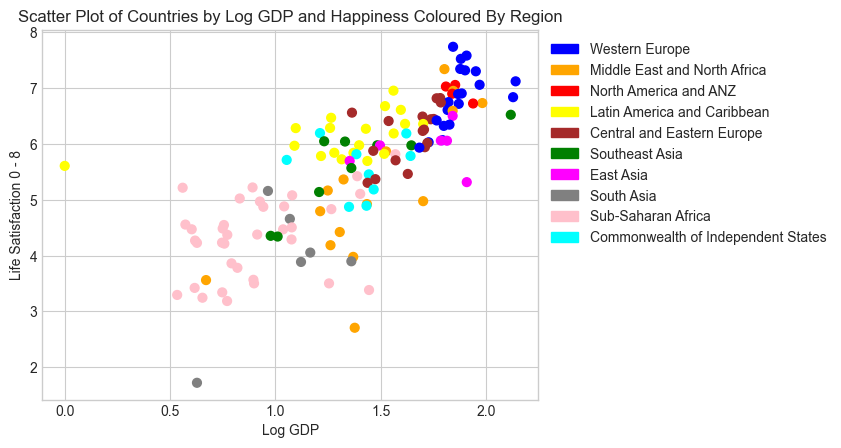

In [70]:
label_to_colour = {i: region_colours[region] for i, region in enumerate(regions)} #Assigning colours defined before to each region, enumerate(regions) gives an index for each region to index through

point_colours = [label_to_colour[i] for i in numerical_regions]

# Plot scatter
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40)

plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Scatter Plot of Countries by Log GDP and Happiness Coloured By Region')

def add_legend():
    region_patches=[
        ptch.Patch(color="Blue",label="Western Europe"),
        ptch.Patch(color="Orange",label="Middle East and North Africa"),
        ptch.Patch(color="Red",label="North America and ANZ"),
        ptch.Patch(color="Yellow",label="Latin America and Caribbean"),
        ptch.Patch(color="Brown",label="Central and Eastern Europe"),
        ptch.Patch(color="Green",label="Southeast Asia"),
        ptch.Patch(color="Magenta",label="East Asia"),
        ptch.Patch(color="Grey",label="South Asia"),
        ptch.Patch(color="Pink",label="Sub-Saharan Africa"),
        ptch.Patch(color="Cyan",label="Commonwealth of Independent States")]
    
    plt.legend(handles=region_patches,bbox_to_anchor=(1,1))

add_legend()
plt.show()

## The Graph
The graph above is the result of colour coding each country according to the region they come from. Their positions also correspond to their ladder score (Life Satisfaction) and Log GDP, with both axes starting from 0 to the next value rounded up from the highest value in each axis. 

## Training The Model And Predictions
Initially, the model was trained to classify by "happy" or "sad" depending on if the countries ladder score is less than or greater than or equal to 5. This isn't a very good use of the Naive Bayes Classifier as that information could very well be seen by anyone viewing the graph in comparison to the regions each plotted country comes from. Instead a proper category is used from the data set which the column of the corresponding region each country resides in.

Below, the model is being set up and then trained on the coordinates and their label. 2000 random coordinates are also created, the model will classify what region those random points would come from depending on their position on the graph. Both sets of coordinates will be scattered for comparison purposes and will be outputted on the same graph alongside the certainty of the model as to which of the final 8 plotted points belongs to each region. 

'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'


array([[0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.07, 0.  , 0.92, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.48, 0.  , 0.17, 0.02, 0.34, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.13, 0.  , 0.85, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.06, 0.  , 0.93, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.11, 0.  , 0.88, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.17, 0.  , 0.81, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.43, 0.  , 0.37, 0.  , 0.2 , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.05, 0.  , 0.8 , 0.  , 0.14, 0.  ]])

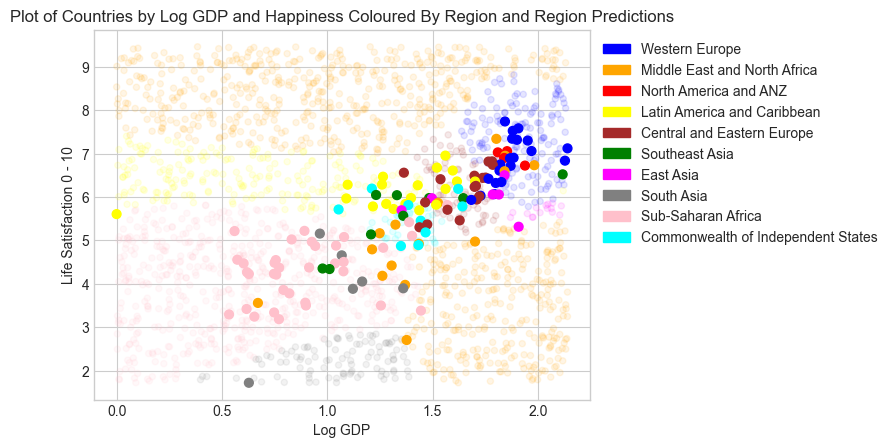

In [71]:
model = GaussianNB() #Using the Gaussian Naive Bayes model
model.fit(coordinates, numerical_regions); 

rng = np.random.RandomState(0)
Xnew = [logGDP.min(), happiness.min()] + [logGDP.max(), happiness.max()] * rng.rand(2000, 2) #Choosing X and Y ranges for randomly generated points (min and max values of the columns)
ynew = model.predict(Xnew) #Making predictions on Xnew
ynew_point_colours = [label_to_colour[i] for i in ynew] #Setting up colours in ynew for plot.scatter

plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew_point_colours, s=20, alpha=0.1)

plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40); #y is array with 1 or 0 where a unique color is assigned, s determines size, cmap = red blue

lim = plt.axis() #Returns current axis limits
plt.axis(lim); #Basing the axis on the limits of the data

plt.xlabel('Log GDP') #Adding labels for x and y
plt.ylabel('Life Satisfaction 0 - 10')
plt.title('Plot of Countries by Log GDP and Happiness Coloured By Region and Region Predictions') #Adding title
add_legend()

#Attempting to show the corresponding label of the array output to show the certainties of each region
print("'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'")
yprob = model.predict_proba(coordinates) #Getting probabilities of the certainty that the labels are what they should be assigned to 
yprob[-8:].round(2) #Rounding probabilities to 2 decimal points

### Graph And Region Predictions Of Randomised Points
The graph above shows the predicted regions of each of the randomly generated points as the faded circles while the hard circles are the actual classified countries. Some predictions may be obscured by the hard circles as the prediction of North America and ANZ is covered. Using the graph below, the predictions for Southeast Asia in terms of the randomised points never appear and where they may have commonly appeared seems to be spread among a few other regions with more countries in general, affecting the predictions for that region.

### Western Europe, East Asia, Central and Eastern Europe
By observing the graph, countries with a satisfaction of around six to nine with a log GDP of over 1.5 are mostly classified as Western Europe. Despite having a similar Log GDP to Western Europe, the predicted values for East Asia appears to have lower overall life satisfaction by one point in terms of the predicted regions. Some of the Central and Eastern Europe predictions also appear to somewhat match the happiness seen in Western Europe, even with a slightly lower log GDP. This may answer the question that there in fact can be regions with similar Log GDPs but a different ladder score or life satisfaction as predicted by the model. Due to this, other columns in the data set such as indication of feelings of being allowed to make one's decisions and also the feelings of social support may also have a great effect on regions such as Central and Eastern Europe.

### Sub-Saharan Africa, South Asia
The regions of Sub-Saharan Africa and South Asia appear to be in the lower to mid half in terms of life satisfaction and also behind most regions in terms of Log GDP yet with many plotted Sub-Saharan Africa points ending up behind South Asia, it appears the model predicts that South Asia may still overall be below Sub-Saharan Africa in terms of life satisfaction based on the cluster of its predicted points. This could point to the fact that different countries may even have lower Log GDPs and still be at a higher level of life satisfaction overall. However the predictions for the Commonwealth of Independent States may very well be affected by Afghanistan being the lowest rated in country in terms of happiness. 

### Commonwealth of Independent States
For the region of the Commonwealth of Independent States, has a cluster between the Log GDP of 1.0 to 1.5 and a Ladder Score of 5 to 6 in terms of the randomised points. Given that the predicted points classified as Commonwealth of Independent States has a lower overall happiness than the Latin America And Carribbean region despite having a similar GDP, it does appear that the Log GDP may not have much of an effect on this region's happiness.

### Latin America And Carribbean
Most countries in this region share a similar Log GDP and happiness to Southeast Asia and the Commonwealth of Independent States aside from the biggest outlier for that region as well as most of the graph as Venezuela had a Log GDP of 0 in 2024 yet a life satisfaction level that goes over 5, which may affect the model's predictions. The outlier in Venezuela also shows that a poorly performing economy will definitely not always directly affect happiness, though this country is an outlier, especially when compared to the other countries in its region.

### Middle East And North Africa 
This region has many countries that are spread out over the graph with some countries in the region being among the happiest and also doing well economically, causing the predictions to be heavily spread out over the entire graph in which the randomised  points below a happiness of 5 with a Log GDP of over 1.5 would classified as from this region and also randomised points with a lower Log GDP but also have a happiness of over 7 could be classified as from this region as well. The wide variety of where countries from this region place implies that the Log GDP has an inconsistent relationship with happiness.

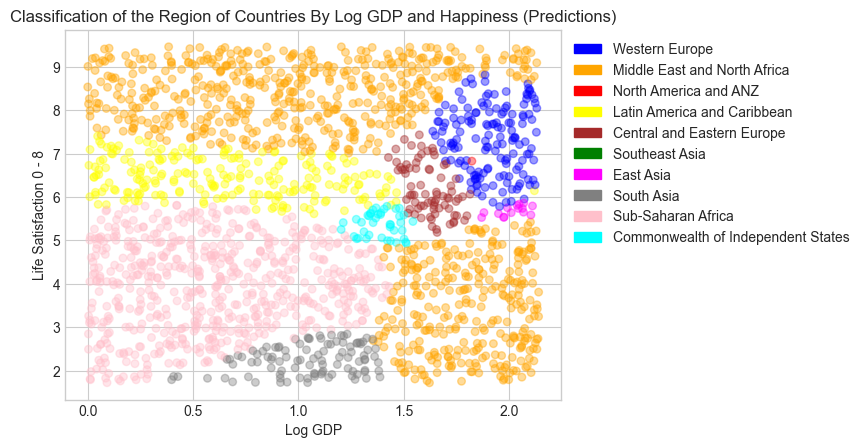

In [72]:
model = GaussianNB() #Using the Gaussian Naive Bayes model
model.fit(coordinates, numerical_regions); 

rng = np.random.RandomState(0)
Xnew = [logGDP.min(), happiness.min()] + [logGDP.max(), happiness.max()] * rng.rand(2000, 2) #Choosing X and Y ranges for randomly generated points (min and max values of the columns)
ynew = model.predict(Xnew) #Making predictions on Xnew
ynew_point_colours = [label_to_colour[i] for i in ynew] #Setting up colours in ynew for plot.scatter

plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew_point_colours, s=30, alpha=0.4)

lim = plt.axis() #Returns current axis limits
plt.axis(lim); #Basing the axis on the limits of the data

plt.xlabel('Log GDP') #Adding labels for x and y
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Classification of the Region of Countries By Log GDP and Happiness (Predictions)') #Adding title
add_legend()

yprob = model.predict_proba(coordinates) #Getting probabilities of the certainty that the labels are what they should be assigned to 

The output above are purely the predicted regions of the randomised points to see more clearly as they're now unobscured from the real points of the graph.

## Evaluating The Model
Below the train, test set split and predictions are set up and outputted. The outputted test predictions seem to roughly follow the actual results with very similar Western Europe and Sub-Saharan Africa predictions with some incorrect predictions such as with Central and Eastern Europe being predicted where the Latin America and Caribbean region should be.

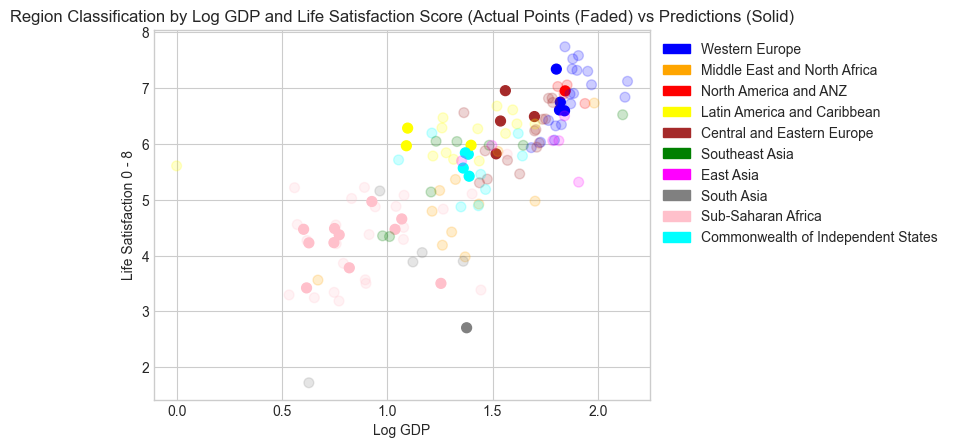

In [73]:
le = LabelEncoder()
numerical_regions = le.fit_transform(df['Regional indicator'])  #Converting categorical data (regions) to numerical format (Regions are listed alphabetically and then indexed)

X_train, X_test, y_train, y_test = train_test_split(coordinates, numerical_regions, test_size=0.2, random_state=42) # Split data into 80% training and 20% test set

model = GaussianNB() 
model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  # Predict using the test data
ypred_point_colours = [label_to_colour[i] for i in y_pred] #Setting up colours in y_pred for plot.scatter due to the number of points in training and testing sets
ytrain_point_colours = [label_to_colour[i] for i in y_train] #Setting up colours in y_train for plot.scatter

plt.scatter(X_test[:, 0], X_test[:, 1], c=ypred_point_colours, s=50) 
plt.scatter(X_train[:, 0], X_train[:, 1], c=ytrain_point_colours, s=50, alpha=0.2)
plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Region Classification by Log GDP and Life Satisfaction Score (Actual Points (Faded) vs Predictions (Solid)')
add_legend()

In [74]:
#Getting classification report of the model and replacing supports/regions that aren't included in the test set with 0
report = classification_report(y_test, y_pred, labels=range(len(le.classes_)), target_names=le.classes_, zero_division=0) 
print(report)

                                    precision    recall  f1-score   support

        Central and Eastern Europe       0.50      1.00      0.67         2
Commonwealth of Independent States       0.25      1.00      0.40         1
                         East Asia       0.00      0.00      0.00         0
       Latin America and Caribbean       1.00      0.50      0.67         6
      Middle East and North Africa       0.00      0.00      0.00         4
             North America and ANZ       0.00      0.00      0.00         0
                        South Asia       0.00      0.00      0.00         1
                    Southeast Asia       0.00      0.00      0.00         1
                Sub-Saharan Africa       0.91      0.91      0.91        11
                    Western Europe       0.50      1.00      0.67         2

                          accuracy                           0.64        28
                         macro avg       0.32      0.44      0.33        28
          

## Classification Report
The above classification report shows the precision, recall, f1 score and the number of times each classification/region has shown up in the test set. The accuracy score also ends up at 0.57 or 57% for the model's predictions.

### Sub-Saharan Africa, Latin America and Caribbean
The model itself seems to be very accurate at predicting the Sub-Saharan Africa region, at 0.92 on precision, perfect score on recall, and an f1 score of 0.96. The model also perfectly predicted the region of Latin America and Caribbean however the 0.5 recall implies that the model may have only caught about half of the actual cases of the region being Latin America and Caribbean.

### Middle East and North Africa, South Asia, Southeast Asia
The model was also completely inaccurate at predicting the Middle East and North Africa, South Asia, and Southeast Asia with a score of 0 for all categories, which may be because of how spread out the points for each on the graph and being plotted within clusters of different regions.

### Commonwealth of Independent States, Central and Eastern Europe, Western Europe
The region of the Commonwealth of Independent States, Central and Eastern Europe, and Western Europe all had perfect recall however when predicting either of the three, the model scored 0.50, 0.25, 0.50 respectively meaning the model wasn't too accurate when predicting them but caught all the possible cases of each region being the right answer.

### East Asia and North America and ANZ 
The above regions were never included in the test set.

The code below sets up a confusion matrix for the model.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Central and Eastern Europe'),
  Text(1, 0, 'Commonwealth of Independent States'),
  Text(2, 0, 'East Asia'),
  Text(3, 0, 'Latin America and Caribbean'),
  Text(4, 0, 'Middle East and North Africa'),
  Text(5, 0, 'North America and ANZ'),
  Text(6, 0, 'South Asia'),
  Text(7, 0, 'Southeast Asia'),
  Text(8, 0, 'Sub-Saharan Africa'),
  Text(9, 0, 'Western Europe')])

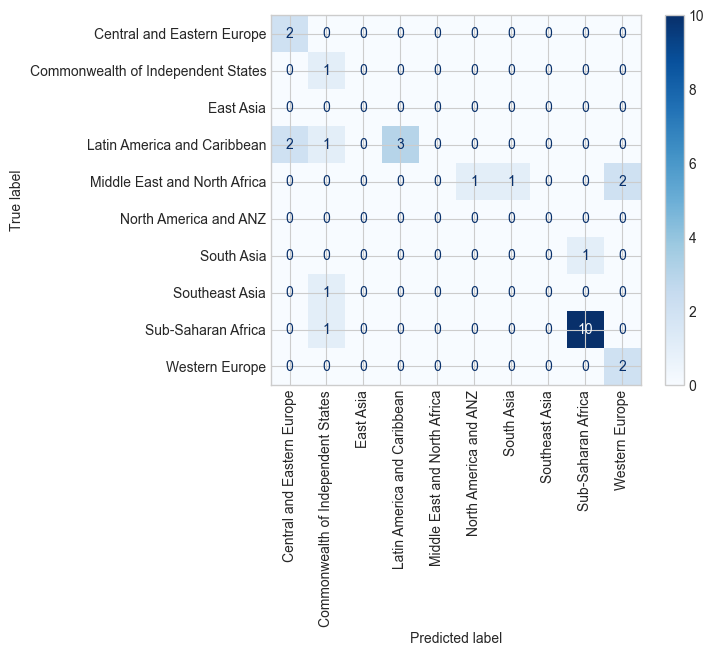

In [75]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_) #creating confusion matrix with the labels as the label encoder's classes
cm_display.plot(cmap=plt.cm.Blues)  
plt.xticks(rotation=90)

## Confusion Matrix
The confusion matrix above shows the right and wrong predictions, with what's being read horizontally being the actual label while what's being read vertically is what was predicted, meaning that the points are ideally going to the right diagonally. The model appears to do well in predicting Sub-Saharan Africa with 10/11 correct predictions. Notably, the Middle East and North Africa were never predicted correctly however which may be due to the fact that predictions for the region are spread out across the graph rather than in a cluster. 

## Setting Up Data For Log GDP And Life Expectancy
The cell below uses the same code as before but replaces the ladder score column with the life expectancy for a country which is based on the average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages. 

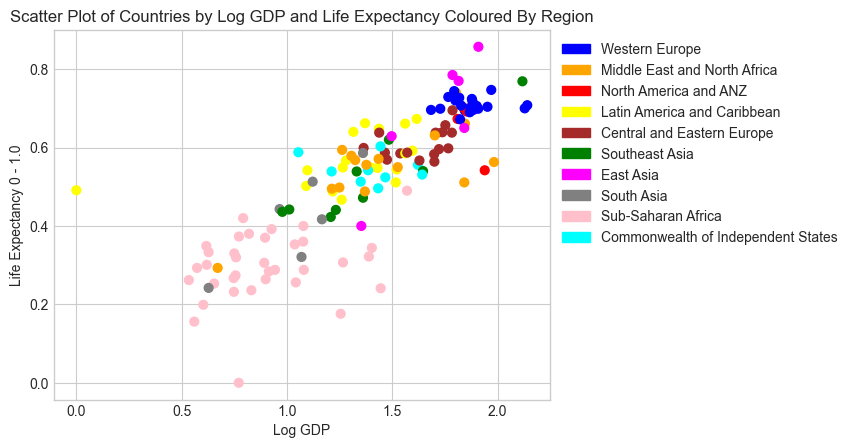

In [76]:
#Importing Dependencies
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.patches as ptch 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import seaborn as sns

df = pd.read_csv('World-happiness-report-2024.csv').dropna() #Dropping columns with missing data and reading the dataset 

logGDP = df['Log GDP per capita'].values  #Using .values as reading with pandas turns the data into a different format (pandas series) 
life_expectancy = df['Healthy life expectancy'].values
regional_indicator = df['Regional indicator'].values

plt.style.use('seaborn-v0_8-whitegrid')
coordinates = np.column_stack((logGDP, life_expectancy)) #Using column_stack method to create a 2d array representing coordinates using the Log GDP and Ladder Score

label_to_colour = {i: region_colours[region] for i, region in enumerate(regions)} #Assigning colours defined before to each region, enumerate(regions) gives an index for each region to index through

point_colours = [label_to_colour[i] for i in numerical_regions]

# Plot scatter
plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40)

plt.xlabel('Log GDP')
plt.ylabel('Life Expectancy 0 - 1.0')
plt.title('Scatter Plot of Countries by Log GDP and Life Expectancy Coloured By Region')

def add_legend():
    region_patches=[
        ptch.Patch(color="Blue",label="Western Europe"),
        ptch.Patch(color="Orange",label="Middle East and North Africa"),
        ptch.Patch(color="Red",label="North America and ANZ"),
        ptch.Patch(color="Yellow",label="Latin America and Caribbean"),
        ptch.Patch(color="Brown",label="Central and Eastern Europe"),
        ptch.Patch(color="Green",label="Southeast Asia"),
        ptch.Patch(color="Magenta",label="East Asia"),
        ptch.Patch(color="Grey",label="South Asia"),
        ptch.Patch(color="Pink",label="Sub-Saharan Africa"),
        ptch.Patch(color="Cyan",label="Commonwealth of Independent States")]
    
    plt.legend(handles=region_patches,bbox_to_anchor=(1,1))

add_legend()
plt.show()

## The Graph
The graph above is the result of colour coding each country according to the region they come from. Their positions also correspond to their life expectancy and Log GDP, with both axes starting from 0 to the next value rounded up from the highest value in each axis. Many regions do appear around the 1.5 Log GDP range and at 0.5 to 0.7 Life Expectancy scores which may affect the graph's predictions. 

'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.04, 0.01, 0.95, 0.  ],
       [0.  , 0.  , 0.01, 0.  , 0.01, 0.  , 0.08, 0.04, 0.86, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.97, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.99, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.98, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.04, 0.  , 0.96, 0.  ],
       [0.05, 0.46, 0.01, 0.25, 0.15, 0.  , 0.01, 0.07, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.98, 0.  ]])

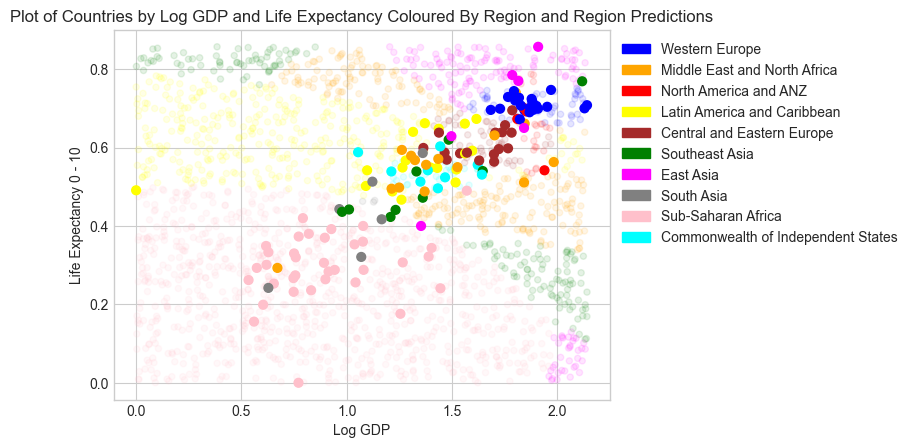

In [77]:
model = GaussianNB() #Using the Gaussian Naive Bayes model
model.fit(coordinates, numerical_regions); 

rng = np.random.RandomState(0)
Xnew = [logGDP.min(), life_expectancy.min()] + [logGDP.max(), life_expectancy.max()] * rng.rand(2000, 2) #Choosing X and Y ranges for randomly generated points (min and max values of the columns)
ynew = model.predict(Xnew) #Making predictions on Xnew
ynew_point_colours = [label_to_colour[i] for i in ynew] #Setting up colours in ynew for plot.scatter

plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew_point_colours, s=20, alpha=0.1)

plt.scatter(coordinates[:, 0], coordinates[:, 1], c=point_colours, s=40); #y is array with 1 or 0 where a unique color is assigned, s determines size, cmap = red blue

lim = plt.axis() #Returns current axis limits
plt.axis(lim); #Basing the axis on the limits of the data

plt.xlabel('Log GDP') #Adding labels for x and y
plt.ylabel('Life Expectancy 0 - 10')
plt.title('Plot of Countries by Log GDP and Life Expectancy Coloured By Region and Region Predictions') #Adding title
add_legend()

#Attempting to show the corresponding label of the array output to show the certainties of each region
print("'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'")
yprob = model.predict_proba(coordinates) #Getting probabilities of the certainty that the labels are what they should be assigned to 
yprob[-8:].round(2) #Rounding probabilities to 2 decimal points

### Graph And Region Predictions Of Randomised Points
The graph above shows the predicted regions of each of the randomly generated points as the faded circles while the hard circles are the actual classified countries. Some predictions may be obscured by the hard circles as the prediction of North America and ANZ is covered, similarly to the previous graph that used Log GDP and Ladder Score. Contrary to the previous model's regional predictions, Southeast Asia now shows up for predictions alongside more North America and ANZ predictions.

### East Asia
The East Asia region appears to have the highest life expectancy predictions for its GDP and also the lowest as its colours can be seen in the bottom right. This may however, be due to Mongolia having a life expectancy of 0.4 which is less than half of the country in its region and in the graph in general with the highest life expectancy greater than 0.8.

### Southeast Asia
With actual predictions for this region coming from the model, it can now be seen that the country tends to stay within the highest life expectancy predictions at the lower GDPs and also near the lower end, reaching below 0.2 for life expectancy at the higher GDPs. The majority of countries in the Southeast Asia region are plotted near the middle of the graph, however Singapore being an outlier for that region in terms of both life expectancy and Log GDP may heavily affect the predictions for that region.

### Central and Eastern Europe, Western Europe, North America And ANZ
Both Central and Eastern Europe and North America And ANZ region predictions seem to be in very similar positions in terms of life expectancy despite the Central and Eastern Europe region having a lower Log GDP. Western Europe predictions for a healthy life expectancy overall seems to be higher even if the Log GDP may overlap with some points in each region, implying that there's more to Log GDP in regards to what decides a healthy life expectancy.

### Sub-Saharan Africa, South Asia
In comparison to the previous graph, the region of Sub-Saharan Africa now take up the majority of the bottom half rather tha just the bottom implying that just the economic wealth of a country may not be enough to bring the life expectancy up. South asia has far less predictions and without Afghanistan being an outlier for the ladder score its predictions rest in the middle of the graph.

### Commonwealth of Independent States
The region of the Commonwealth of Independent States, has a cluster between the Log GDP of 1.0 to about 1.6, which is higher than the predictions for the previous graphs and a Healthy Life Expectancy of about 0.5 to 0.6 in terms of the randomised points. Given that the predicted points classified as Commonwealth of Independent States has a lower overall healthy life expectancy than a region like Central and Eastern Europe where the Log GDPs may overlap further reinforcing that the Log GDP does not have a large effect on the healthy life expectancy in some regions.

### Middle East And North Africa 
Similarly to the previous graph, the region tends to be among the highest in the lower Log GDPs but is closer to the middle in regards to life expectancy at the higher Log GDPs due to how spread out the countries are in the in terms of Log GDP ranging from between 1.0 and 1.5 to 2.0, however they seem to have similar healthy life expectancies.

### Latin America And Carribbean
The predictions for this region are heavily affected once again by Venezuela being a massive outlier in terms of Log GDP but still shows that economic wealth is not all there is to both happiness or a healthy life expectancy.

'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'


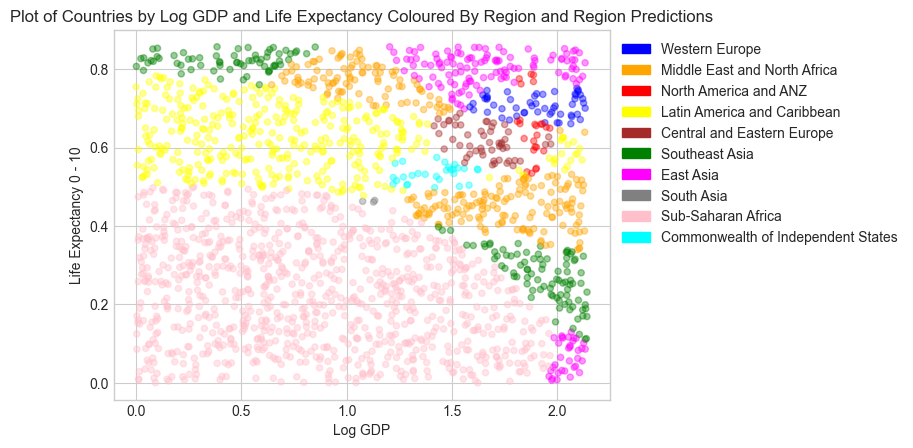

In [78]:
model = GaussianNB() #Using the Gaussian Naive Bayes model
model.fit(coordinates, numerical_regions); 

rng = np.random.RandomState(0)
Xnew = [logGDP.min(), life_expectancy.min()] + [logGDP.max(), life_expectancy.max()] * rng.rand(2000, 2) #Choosing X and Y ranges for randomly generated points (min and max values of the columns)
ynew = model.predict(Xnew) #Making predictions on Xnew
ynew_point_colours = [label_to_colour[i] for i in ynew] #Setting up colours in ynew for plot.scatter

plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew_point_colours, s=20, alpha=0.4)

lim = plt.axis() #Returns current axis limits
plt.axis(lim); #Basing the axis on the limits of the data

plt.xlabel('Log GDP') #Adding labels for x and y
plt.ylabel('Life Expectancy 0 - 10')
plt.title('Plot of Countries by Log GDP and Life Expectancy Coloured By Region and Region Predictions') #Adding title
add_legend()

#Attempting to show the corresponding label of the array output to show the certainties of each region
print("'Central and Eastern Europe''Commonwealth of Independent States''East Asia''Latin America and Caribbean''Middle East and North Africa''North America and ANZ''South Asia''Southeast Asia''Sub-Saharan Africa''Western Europe'")
yprob = model.predict_proba(coordinates) #Getting probabilities of the certainty that the labels are what they should be assigned to 

The output above is purely the predicted regions of the randomised points to see more clearly as they're now unobscured from the real points of the graph.

## Evaluating The Model
Below the evaluation of the model's predictions for Log GDP and Healthy Life Expectancy are performed the same way as the model's predictions for Log GDP and Ladder Score. With the current columns, the model actually seems to be less accurate than the columns involving Log GDP and Ladder Score at 57% if rounding to the nearest whole number. This may be due to the fact that countries of different regions are more clustered together at around 1.5 Log GDP.

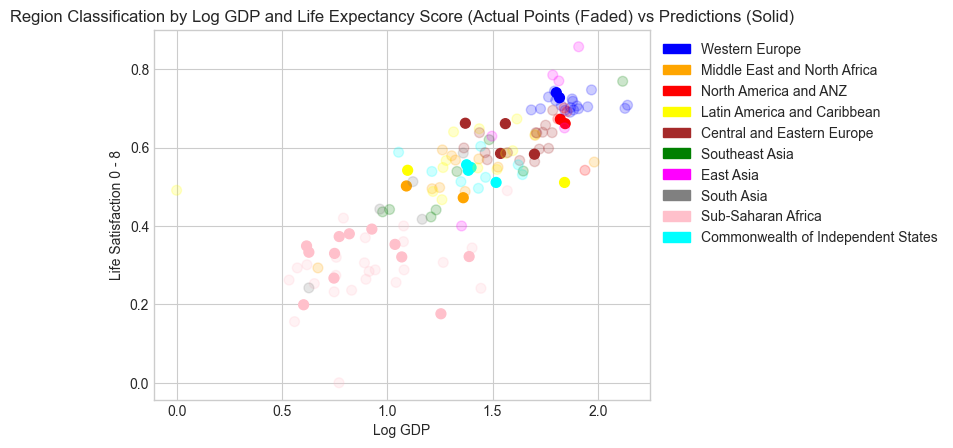

In [79]:
le = LabelEncoder()
numerical_regions = le.fit_transform(df['Regional indicator'])  #Converting categorical data (regions) to numerical format (Regions are listed alphabetically and then indexed)

X_train, X_test, y_train, y_test = train_test_split(coordinates, numerical_regions, test_size=0.2, random_state=42) # Split data into 80% training and 20% test set

model = GaussianNB() 
model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  # Predict using the test data
ypred_point_colours = [label_to_colour[i] for i in y_pred] #Setting up colours in y_pred for plot.scatter due to the number of points in training and testing sets
ytrain_point_colours = [label_to_colour[i] for i in y_train] #Setting up colours in y_train for plot.scatter

plt.scatter(X_test[:, 0], X_test[:, 1], c=ypred_point_colours, s=50) 
plt.scatter(X_train[:, 0], X_train[:, 1], c=ytrain_point_colours, s=50, alpha=0.2)
plt.xlabel('Log GDP')
plt.ylabel('Life Satisfaction 0 - 8')
plt.title('Region Classification by Log GDP and Life Expectancy Score (Actual Points (Faded) vs Predictions (Solid)')
add_legend()

In [80]:
report = classification_report(y_test, y_pred, labels=range(len(le.classes_)), target_names=le.classes_, zero_division=0) #Getting Classification Rerport
print(report)

                                    precision    recall  f1-score   support

        Central and Eastern Europe       0.50      1.00      0.67         2
Commonwealth of Independent States       0.25      1.00      0.40         1
                         East Asia       0.00      0.00      0.00         0
       Latin America and Caribbean       0.50      0.17      0.25         6
      Middle East and North Africa       0.00      0.00      0.00         4
             North America and ANZ       0.00      0.00      0.00         0
                        South Asia       0.00      0.00      0.00         1
                    Southeast Asia       0.00      0.00      0.00         1
                Sub-Saharan Africa       0.92      1.00      0.96        11
                    Western Europe       0.50      0.50      0.50         2

                          accuracy                           0.57        28
                         macro avg       0.27      0.37      0.28        28
          

## Classification Report
The above classification report shows the precision, recall, f1 score and the number of times each classification/region has shown up in the test set when predicting regions based on Log GDP and Life Expectancy. 

### Sub-Saharan Africa
The model itself seems to be very accurate at predicting the Sub-Saharan Africa region, reaching 0.92 on precision, a perfect recall score, and an f1 score of 0.96.

### Middle East and North Africa, South Asia, Southeast Asia
The model was also completely inaccurate at predicting the Middle East and North Africa, South Asia, and Southeast Asia with a score of 0 for all categories once again, which may be because of how spread out the points for each on the graph and being plotted within clusters of different regions despite the different feature sets.

### Commonwealth of Independent States, Central and Eastern Europe
The region of the Commonwealth of Independent States and Central and Eastern Europe all had perfect recall however when predicting either of the two, the model scored 0.25, 0.50, respectively meaning the model wasn't too accurate when predicting them but caught all the possible cases of each region being the right answer.

### Western Europe
In comparison to predicting regions based on the previous feature sets, when predicting based on Life Expectancy, the precision stayed similar however the recall has been reduced by half, leading to a lower f1 score. The model only seemed to predict correctly half the time and also only caught half of the instances Western Europe should have been predicted.

### Latin America and Caribbean
The predictions for Latin America and Caribbean have also been much lower at 0.5 in comparison to its perfect predictions in the last evaluation and the recall is even lower at 0.17 showing that the model is not very accurate at predicting this region based on Log GDP and Life Expectancy, which may be due to how countries from this region also tend to cluster within other regions

### East Asia and North America and ANZ 
The above regions were never included in the test set. 

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Central and Eastern Europe'),
  Text(1, 0, 'Commonwealth of Independent States'),
  Text(2, 0, 'East Asia'),
  Text(3, 0, 'Latin America and Caribbean'),
  Text(4, 0, 'Middle East and North Africa'),
  Text(5, 0, 'North America and ANZ'),
  Text(6, 0, 'South Asia'),
  Text(7, 0, 'Southeast Asia'),
  Text(8, 0, 'Sub-Saharan Africa'),
  Text(9, 0, 'Western Europe')])

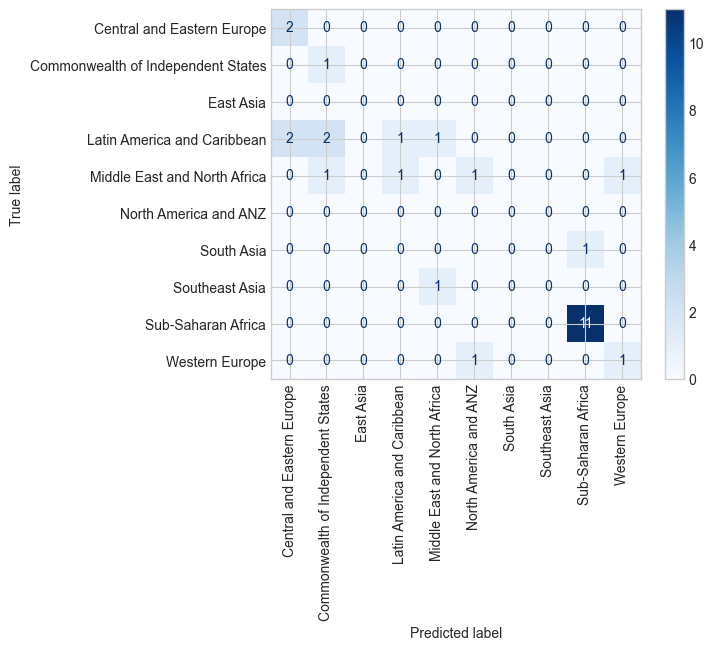

In [81]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_) #creating confusion matrix with the labels as the label encoder's classes
cm_display.plot(cmap=plt.cm.Blues)  
plt.xticks(rotation=90)

## Confusion Matrix
The above confusion matrix shows the model is quite accurate at predicting Sub-Saharan Africa but once again seems to fail at accurately predicting Latin America and Caribbean and the Middle East and North Africa regions given how spread out the Middle East and North Africa region tends to be and Venezuela being an outlier may also heavily affect this.

## Conclusion
In conclusion, after while the model itself is not always correct on predicting the regions of a country based on the columns of the Ladder Score (Life Satisfaction) and Log GDP, it can still show that the Log GDP may not be a very good classifier for a region based on a country's happiness. This is seen when some of the Central And Eastern Europe regions appear to be able to reach the levels of life satisfaction as Western Europe, which has a higher Log GDP. Western Europe itself also seems to have similar Log GDPs as East Asia yet appear to have a higher life satisfaction scores overall. The model further enforces this notion as the predictions for the Sub-Saharan Africa region is still mostly above South Asia, including the points that appear to have a lower Log GDP than South Asia.

Regions with similar Log GDPs but different Ladder Scores are also seen with the region predictions of the randomised points with the Western Europe region and the South Asia region as well.

When predicting based on Log GDP and Healthy Life Expectancy, the model shows that Log GDP shows is still not a good classifier for a region based on a country's healthy life expectancy. This can be seen when the Western Europe region predictions may overlap with Central and Eastern Europe with regards to Log GDP but still have a healthier life expectancy. Outliers such as Mongolia, Venezuela and Singapore very likely had an affect on the model's predictions as well making it less accurate. The predictions for Sub-Saharan Africa for both types of predictions seem to be very accurate at least.

However, despite the models predictions, it appears to be correct 64% of the time according to the accuracy score for the Log GDP and Ladder Score columns and 57% for the Log GDP and Healthy Life Expectancy columns. This may be due to outliers such as Venezuela having a Log GDP of 0 yet a life satisfaction score in between 5 and 6 which strays away from most of the countries classified as Latin America And Caribbean region, as well as Afghanistan having a much lower score in comparison to the rest of South Asia and nearly every other country as seen on the graph of actual points when predicting Log GDP and Ladder Score. With 